# Vorstellung des Projekts
In diesem Projekt werden anhand eines realen Datensatzes Hausverkaufspreise vorhersagen, wobei der Schwerpunkt auf der weitestgehenden Automatisierung des Machine-Learning-Workflows liegt.

- Sweetviz- oder YData-Profiling für die automatisierte EDA
- Featuretools und/oder Autofeat für Feature Engineering
- H2O AutoML und/oder PyCaret zum Erstellen, Optimieren und Auswerten von Regressionsmodellen

# Der Datensatz: Ames Housing

# Alle Import

In [1]:
# 1. IMPORTE (ALLE BIBLIOTHEKEN)
import os
import sys
import multiprocessing
import threading  # WICHTIG: Für den Spinner in der NLP-Abfrage
import warnings
import logging
import requests
import subprocess
import time
import datetime
import re
import json
import sqlite3
import psutil
from pathlib import Path

# Datenhandling & Formate [cite: 2026-01-07]
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import inspect
import scipy

# Visualisierung & Plot-Fenster-Schutz
import matplotlib
matplotlib.use('Agg') # Verhindert "eklige" Pop-up-Fenster [cite: 2026-02-05]
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

# Automatisierte EDA [cite: 2026-01-29]
import ydata_profiling as yp
import sweetviz as sv
import sklearn
from IPython.display import display, IFrame

# Machine Learning & AutoML [cite: 2025-12-29]
import h2o
from h2o.automl import H2OAutoML
import joblib
from sklearn.metrics import mean_squared_error, r2_score
try:
    from pycaret.regression import setup, compare_models, finalize_model
except ImportError:
    pass

# Feature Engineering
from autofeat import AutoFeatRegressor
import featuretools as ft

# NLP & PandasAI (Ollama/LocalLLM Support)
import pandasai
from pandasai import SmartDataframe
from pandasai.llm.base import LLM
from pandasai import llm as llm_module

# Sicherer Import für ResponseParser
try:
    from pandasai.responses.response_parser import ResponseParser
except ImportError:
    try:
        from pandasai.handlers.response_parser import ResponseParser
    except ImportError:
        ResponseParser = object

try:
    from pandasai.llm.local_llm import LocalLLM
except ImportError:
    pass

# Performance & Monitoring [cite: 2025-11-02]
from tqdm.notebook import tqdm

# 2. SYSTEM-KONFIGURATION & PROTOKOLL
if 'df_Protocol' not in locals():
    df_Protocol = pd.DataFrame(columns=["Schritt", "Entscheidung", "Begründung", "Metrik"])

total_cores = multiprocessing.cpu_count()
cores_to_use = max(1, total_cores - 1)

# H2O-Logs & Java-Fix
logging.getLogger("h2o").setLevel(logging.ERROR)
os.environ['H2O_DISABLE_LOGGING'] = '1'

conda_java_path = os.path.join(sys.prefix, 'lib', 'jvm', 'bin', 'java')
os.environ['JAVA_HOME'] = os.path.join(sys.prefix, 'lib', 'jvm')
os.environ['JAVA_EXE'] = conda_java_path
os.environ['PATH'] = os.path.dirname(conda_java_path) + os.pathsep + os.environ.get('PATH', '')

# Patch für scipy.interp
if not hasattr(scipy, "interp"):
    try:
        from numpy import interp; scipy.interp = interp
    except ImportError: pass

warnings.filterwarnings("ignore")


In [ ]:
import re
import requests
import os
import scipy

# 3. PANDASAI-KOMPATIBLER LLM-ADAPTER (Ollama V12 - FILE-LOAD-PROTECT)
class OllamaPandasAIAdapter(LLM):
    """Vollständig PandasAI-kompatibler Adapter - verhindert FileNotFoundError & MaliciousQuery."""

    def __init__(self, model_name: str = "llama3"):
        super().__init__()
        self.model_name = model_name

    @property
    def type(self) -> str:
        return "ollama_pandasai_v12"

    def call(self, instruction: str, context: str = None, **kwargs) -> str:
        """Fix für TypeError: Prompt-Objekt zu String casten."""
        return self.generate(str(instruction), context=context)

    def generate(self, prompt: str, context: str = None, **kwargs) -> str:
        """Hauptmethode mit 3-Wege-Logik: Text, Code oder Plot."""

        frage_clean = str(prompt).upper()

        # LOGIK-WEICHE
        # MÖGLICHKEIT 3: PLOT (Grafik + Tabelle + Erklärung)
        if "PLOT" in frage_clean or "GRAFIK" in frage_clean:
            system_prompt = """Du bist Daten-Analyst.
            1. Erstelle Python-Code für einen Plot (Nutze NUR execute_sql_query).
            2. Erstelle eine Tabelle der wichtigsten Daten darunter.
            3. Erkläre am Ende fachlich, was die Grafik und die Werte bedeuten.
            ANTWORTE: Erst Code in ```python ... ```, dann Text-Erklärung."""

        # MÖGLICHKEIT 2: CODE (Nur Python - STRENGER MODUS)
        elif "CODE" in frage_clean:
            system_prompt = """Du bist ein reiner Python-Code-Generator.
            ANTWORTE AUSSCHLIESSLICH mit Code in ```python ... ```.
            Jedes Wort außerhalb der Code-Backticks ist streng verboten.
            Keine Einleitung, keine Erklärungen, kein 'Hier ist dein Code'."""

        # MÖGLICHKEIT 1: TEXT (Rein narrative Analyse)
        else:
            system_prompt = """Du bist ein erfahrener Mentor und Data Scientist.
            Antworte REIN TEXTLICH. Nutze KEINEN Code, KEIN SQL, KEINE Zahlen-Tabellen."""

        # API AUFRUF
        full_prompt = f"{system_prompt}\n\nFrage: {str(prompt)}"
        url = "http://localhost:11434/api/generate"
        payload = {
            "model": self.model_name,
            "prompt": full_prompt,
            "stream": False,
            "options": {
                "temperature": 0.0 if "CODE" in frage_clean else 0.2, # 0.0 erzwingt Präzision
                "top_p": 0.9,
                "num_predict": 800 if "CODE" in frage_clean else 2000 # Spart Zeit bei Code
            }
        }

        try:
            response = requests.post(url, json=payload, timeout=None)
            response.raise_for_status()
            roh_antwort = response.json().get("response", "")

            # DER FILTER: Extrahiert nur den Code-Block
            if "CODE" in frage_clean:
                code_match = re.search(r'```python\s*(.*?)\s*```', roh_antwort, re.DOTALL)
                if code_match:
                    # Gibt NUR den Code-Block zurück
                    return f"```python\n{code_match.group(1).strip()}\n```"

                # Fallback: Falls Ollama die Backticks vergessen hat, aber Code liefert
                if "import " in roh_antwort or "pd." in roh_antwort:
                    return f"```python\n{roh_antwort.strip()}\n```"

            return roh_antwort

        except Exception as e:
            return f'print("Fehler bei Ollama: {e}")'

    def generate_code(self, prompt, context=None, **kwargs) -> str:
        """
        Dynamischer Code-Generator mit:
        1. SQL-Keyword-Schutz (Fix für 'Order' Fehler)
        2. Squeezer-Modus (Performance MacBook Air)
        3. Automatischer Plot-Sicherung
        """
        prompt_str = str(prompt)
        table_match = re.search(r'table_name="([^"]+)"', prompt_str)
        t_name = table_match.group(1) if table_match else "df_data"

        raw_response = self.generate(prompt_str)

        # 1. Code extrahieren
        code_match = re.search(r'```python\s*(.*?)\s*```', raw_response, re.DOTALL)
        logic_code = code_match.group(1).strip() if code_match else raw_response.strip()

        # --- SYNTAX- & SQL-FIXES ---
        # A) Entfernt SQL-Kommentare (#), die 'invalid syntax' verursachen
        logic_code = re.sub(r'#.*', '', logic_code)

        # B) SQL-KEYWORD-SCHUTZ: Setzt geschützte Namen wie 'Order' in Anführungszeichen
        # dies verhindert den "Catalog Error: Table with name Order does not exist"
        logic_code = re.sub(r'FROM\s+Order', f'FROM "{t_name}"', logic_code, flags=re.IGNORECASE)
        logic_code = re.sub(r'SELECT\s+Order', f'SELECT * FROM "{t_name}"', logic_code, flags=re.IGNORECASE)

        # C) Erzwingt LIMIT 10 bei Plots für MacBook Air Speed
        if "PLOT" in prompt_str.upper() or "BAR" in logic_code.lower():
            if "LIMIT" not in logic_code.upper():
                logic_code = logic_code.replace(f'FROM "{t_name}"', f'FROM "{t_name}" LIMIT 10')

        # D) Triple-Quote-Schutz & Platzhalter-Korrektur
        logic_code = logic_code.replace('"""', "'''")
        logic_code = re.sub(r'your_table_name|table_name|housing', t_name, logic_code, flags=re.IGNORECASE)

        # 2. HARD-CORRECTION: pd.read_csv Fix
        logic_code = re.sub(r'pd\.read_csv\(.*?\)', f'execute_sql_query("SELECT * FROM {t_name}")', logic_code)

        # 3. PLOT-SICHERUNG: Erzwingt Speichern des Charts, falls LLM es vergisst
        if "plt." in logic_code and "plt.savefig" not in logic_code:
            logic_code += "\nplt.savefig('temp_chart.png')\nprint('CHART_CREATED')"

        # 4. Sicherstellen, dass execute_sql_query vorhanden ist
        if "execute_sql_query" not in logic_code:
            logic_code = f'df_data = execute_sql_query("SELECT * FROM {t_name}")\n' + logic_code

        # FINALES MUSTER (SQUEEZER & SQL-SAFE)
        perfect_code = f'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# FORMAT-CHECK & DATA ACQUISITION (SQUEEZER)
def get_safe_data():
    potential_sources = [
        lambda: globals().get('df_ML'),
        lambda: globals().get('df'),
        lambda: locals().get('{t_name}'),
        lambda: globals().get('{t_name}')
    ]

    source = None
    for s_call in potential_sources:
        try:
        except:
            continue

    if source is not None:
        try:
            # SQUEEZER: Reduziert RAM-Last
            code_ref = {repr(logic_code)}
            detected = [c for c in source.columns if c in code_ref]
            if detected:
                for c in ['Order', 'PID', 'SalePrice']:
                    if c in source.columns and c not in detected:
                        detected.append(c)
                return source[detected].copy()
        except:
            pass
        return source

    return execute_sql_query("SELECT * FROM {t_name}")
        except: pass
        return source

    return execute_sql_query("SELECT * FROM {t_name}")

df_data = get_safe_data()

# Ausführung der Logik mit einrückung-Schutz
try:
{re.sub('^', '    ', logic_code, flags=re.MULTILINE)}
except Exception as e:
    print(f"Laufzeitfehler im Code-Block: {{e}}")

# Fallback für Variablen-Benennung
if 'df_data' not in locals() and 'result_df' in locals():
# 4. INITIALISIERUNG (H2O & LLM)
llm = None
h2o_ready = False

try:
    if os.path.exists(conda_java_path):
        h2o.init(
            nthreads=cores_to_use,
            max_mem_size="4G",
            jvm_custom_args=["-Xss4M"],  # Stack-Fix gegen StackOverflowError
            log_level="ERRR",
            log_dir=os.devnull
        )
        llm = OllamaPandasAIAdapter(model_name="llama3")
        print(f"✅ SYSTEM BEREIT: Adapter V12 & H2O ({cores_to_use} Cores genutzt).")
    else:
        print("❌ Java-Binary nicht gefunden.")
except Exception as e:
    print(f"❌ Initialisierung-Fehler: {e}")

# Monkey-Patch & Platzhalter
if not hasattr(scipy, "interp"):
    try:
        from numpy import interp
        scipy.interp = interp
    except ImportError:
        pass

TEMP_Clear = "Allgemeine Bereinigungsvorschläge zum Kopieren"
TEMP_Clear_ML = "Vorschläge zur Vorverarbeitung für ML:"
import scipy
if not hasattr(scipy, "interp"):
    try: from numpy import interp; scipy.interp = interp
    except ImportError: pass

TEMP_Clear = "Allgemeine Bereinigungsvorschläge zum Kopieren"
TEMP_Clear_ML = "Vorschläge zur Vorverarbeitung für ML:"

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,20 mins 07 secs
H2O_cluster_timezone:,Europe/Berlin
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 20 days
H2O_cluster_name:,H2O_from_python_cristallagus_uyv6y3
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.842 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,7
H2O_cluster_status:,"locked, healthy"


✅ SYSTEM BEREIT: Adapter V12 & H2O (7 Cores genutzt).


In [ ]:
# Block2 LLM 
# Globales Objekt für das "Gedächtnis"
smart_df_persistent = None

def frage_beantworten_und_ausfuehren(frage, Nur_antwort=True, show_spinner=True, Language="DE"):
    """
    Finalisierte Hochleistung-Version für MacBook Air.
    DREI FUNKTIONEN:
    1. CODE: Liefert nur Python-Skripte (schnell).
    2. PLOT: Erstellt Grafiken + Tabellen + Narrative Analyse.
    3. TEXT: Rein fachliche Beratung ohne Code-Ballast.
    """
    global llm, df_Protocol, smart_df_persistent

    # 1. RAM-SCHUTZ & SYSTEM-CLEANUP
    try:
        available_ram = psutil.virtual_memory().available / (1024 ** 3)
        if available_ram < 1.2:
            import gc
            gc.collect()
    except: pass

    logging.getLogger("pandasai").setLevel(logging.ERROR)

    if llm is None:
        print("❌ Fehler: 'llm' ist nicht initialisiert (Ollama prüfen).")
        return

    is_de = Language.upper() == "DE"
    lang_instr = "Antworte bitte auf DEUTSCH." if is_de else "Please answer in ENGLISH."

    # 2. INTUITIONS-CHECK (STRIKTE TRENNUNG)
    frage_upper = frage.upper()
    # Funktion 1: CODE-Modus (Priorität 1)
    ist_code = "CODE" in frage_upper
    # Funktion 2: PLOT-Modus (Priorität 2 - nur wenn nicht explizit CODE verlangt wurde)
    ist_plot = not ist_code and any(k in frage_upper for k in ["PLOT", "GRAFIK", "DIAGRAMM", "CHART", "BARPLOT"])

    # 3. SPINNER ANIMATION (THREADED)
    done = False
    start_time = time.time()

    def animate():
        chars = ['|', '/', '-', '\\']
        idx = 0
        wait_msg = "Analysiere (Lokale GPU)..." if is_de else "Analyzing (Local GPU)..."
        while not done:
            elapsed = int(time.time() - start_time)
            warn = " ⚠️ RAM SWAP?" if elapsed > 60 else ""
            sys.stdout.write(f'\r{wait_msg} {chars[idx % 4]} [{elapsed}s]{warn} ')
            sys.stdout.flush()
            idx += 1
            time.sleep(0.1)
        sys.stdout.write('\r' + ' ' * 70 + '\r')

    if show_spinner:
        t = threading.Thread(target=animate)
        t.daemon = True
        t.start()

    try:
        # 4. DATEN-QUELLE & SQUEEZER (KONTEXT-OPTIMIERUNG)
        source_df = globals().get('df_ML') if 'df_ML' in globals() else globals().get('df')
        if source_df is None:
            raise ValueError("Kein Dataframe (df/df_ML) gefunden.")

        # Squeezer: Verhindert 180s-Freeze durch Spaltenreduktion
        if ist_plot or ist_code:
            cols_to_keep = [c for c in source_df.columns if c.lower() in frage.lower()]
            # Essenzielle Spalten für Housing-Daten/Analysen sichern
            for essential in ['SalePrice', 'Order', 'Neighborhood']:
                if essential in source_df.columns and essential not in cols_to_keep:
                    cols_to_keep.append(essential)

            if len(cols_to_keep) < 2:
                cols_to_keep = source_df.columns[:10].tolist()
            working_df = source_df[cols_to_keep]
        else:
            working_df = source_df

        # --- 5. EXECUTION (DIE 3 WEGE) ---
        antwort = None

        # PFAD 1: REINER CODE-EXPORT (Direkt-Call an Adapter)
        if ist_code:
            # Nutzt den CODE-Modus aus Muster 2 (Blitzschnell ohne SmartDataframe)
            antwort = llm.call(f"CODE: {frage}")

        # PFAD 2: PLOT ODER KOMPLEXE ANALYSE (Smart-Modus)
        elif ist_plot:
            if smart_df_persistent is None or id(smart_df_persistent.dataframe) != id(working_df):
                smart_df_persistent = SmartDataframe(
                    working_df,
                    config={
                        "llm": llm,
                        "enable_cache": True,
                        "use_error_correction_framework": False,
                        "save_charts": True,
                        "custom_head": True
                    }
                )

            # A: Grafik & Tabelle generieren
            antwort_basis = smart_df_persistent.chat(f"{lang_instr} {frage}")

            # B: ZUSATZ-CHECK: Erzwinge REIN TEXTLICHE Analyse (Mentor-Modus)
            stats = working_df.describe().to_string()
            analyse_prompt = f"""
            Analysiere als Senior Data Scientist:
            Statistik: {stats}
            Frage: {frage}
            AUFGABE: Erkläre fachlich Trends und Ausreißer.
            STRENGSTES VERBOT: Keinen Code, keine Backticks (```). Antworte NUR TEXT.
            """
            erlaeuterung = llm.call(f"{lang_instr} {analyse_prompt}")

            # Sicherheit-Netz: Regex filtert Code-Reste hart aus
            erlaeuterung = re.sub(r'```python.*?```', '', erlaeuterung, flags=re.DOTALL)
            erlaeuterung = re.sub(r'```.*?```', '', erlaeuterung, flags=re.DOTALL)

            antwort = f"{antwort_basis}\n\n### 📝 FACHLICHE ANALYSE:\n{erlaeuterung.strip()}"

        # PFAD 3: REIN NARRATIV (Kein Plot, kein Code)
        else:
            antwort = llm.call(f"{lang_instr} Beantworte als Data Scientist rein narrativ: {frage}")

        done = True
        if show_spinner: t.join()

        # 6. FEHLER-CHECK & AUSGABE
        if antwort is None or (isinstance(antwort, str) and "Error" in antwort):
            raise ValueError(f"LLM lieferte eine ungültige Antwort.")

        print("\n" + "—"*40)
        dur = round(time.time() - start_time, 1)

        # Dynamischer Header je nach Funktion
        header = "💻 CODE-EXPORT" if ist_code else ("📊 VISUALISIERUNG & DATEN" if ist_plot else "📝 ANALYSE-REFLECTION")
        print(f"{header} ({dur}s):\n\n{antwort}")
        print("—"*40 + "\n")

    except Exception as e:
        done = True
        if show_spinner: t.join()
        print(f"\n❌ Fehler ({int(time.time()-start_time)}s): {str(e)}")
        print("💡 TIPP: Falls RAM SWAP auftrat, starte den Kernel neu oder nutze 'CODE' für weniger Last.")


# Lade datensatz

In [4]:
# ROBUSTE PFAD-SUCHE
current = Path.cwd()

# Prüfung auf beide Schreibweisen (Source vs Source)
while not (current / "DATA_Source").exists() and not (current / "DATA_source").exists():
    if current.parent == current:
        raise FileNotFoundError("Projekt-Root mit DATA_source oder DATA_Source nicht gefunden")
    current = current.parent

PROJECT_ROOT = current

# Den tatsächlichen Namen des gefundenen Ordners nehmen
DATA_DIR = next(PROJECT_ROOT.glob("DATA_s*"))
CSV_PATH = DATA_DIR / "AmesHousing.csv"
PQ_PATH  = DATA_DIR / "AmesHousing.parquet"

# LADEN & ALS PACKET SPEICHERN
if not PQ_PATH.exists():
    pd.read_csv(CSV_PATH, encoding="latin1").to_parquet(PQ_PATH, index=False)
    print(f"✅ CSV aus {DATA_DIR.name} geladen und als Packet gespeichert.")

# Endgültiger df für die Arbeit
df = pd.read_parquet(PQ_PATH)

# Kurze Kontrolle
print(f"📊 Datensatz bereit: {df.shape}")
df.head(1)

📊 Datensatz bereit: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,None,IR1,Lvl,...,0,None,None,None,0,5,2010,WD,Normal,215000


# 1. Technische Artefakte

## Automatisierte EDA, generiert mit Sweetviz oder YData Profiling

In [5]:
# AUTOMATISIERTE EDA (Unbekannter Datensatz)

# 1. YData Profiling (Tiefe statistische Analyse)
profile = yp.ProfileReport(df, minimal=True, title="Ames Housing Profiling Report")
profile.to_file(PROJECT_ROOT / "EDA_ydata_report.html")

# 2. Sweetviz (Schneller visueller Vergleich / Überblick)
sv_report = sv.analyze(df, pairwise_analysis="off")
sv_report.show_html(filepath=str(PROJECT_ROOT / "EDA_sweetviz_report.html"), open_browser=False)


# DOKUMENTATION DER ERGEBNISSE
print(f"✅ EDA-Berichte generiert im Projekt-Root:")
print(f"   - {PROJECT_ROOT / 'EDA_ydata_report.html'}")
print(f"   - {PROJECT_ROOT / 'EDA_sweetviz_report.html'}")
global df_Protocol
# Entscheidung in df_Protocol protokollieren
new_decision = pd.DataFrame([{
    'Schritt': 'Automatisierte EDA',
    'Entscheidung': 'ydata & sweetviz genutzt',
    'Begründung': 'Vollständige Analyse eines House Sale Prices Datensatzes vor dem ML-Start',
    'Metrik': f'Analysierte Spalten: {len(df.columns)}'
}])
df_Protocol = pd.concat([df_Protocol, new_decision], ignore_index=True)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 82/82 [00:00<00:00, 161.08it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

                                             |          | [  0%]   00:00 -> (? left)

Report /Users/cristallagus/Desktop/GitHub/Public/Projecten/🏘️ Predicting House Sale Prices Automation-Driven/EDA_sweetviz_report.html was generated.
✅ EDA-Berichte generiert im Projekt-Root:
   - /Users/cristallagus/Desktop/GitHub/Public/Projecten/🏘️ Predicting House Sale Prices Automation-Driven/EDA_ydata_report.html
   - /Users/cristallagus/Desktop/GitHub/Public/Projecten/🏘️ Predicting House Sale Prices Automation-Driven/EDA_sweetviz_report.html


In [6]:
profile.to_notebook_iframe()

In [ ]:
display(IFrame(src="EDA_sweetviz_report.html", width="100%", height="800px"))

## Automatisch generierte Features, erstellt mit Autofeat und/oder Featuretools

In [5]:
# AUTOMATISIERTE FEATURE-GENERIERUNG (Erkenntnis: NaN- & String-Handling)

# 1. DATEN VORBEREITEN
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# 2. AUTOMATISIERTE KONVERTIERUNG (Erkenntnis aus Fehlermeldung)
# Schritt A: NaNs füllen (AutoFeat benötigt vollständige Daten)
X_auto = X.fillna(X.mode().iloc[0])

# Schritt B: Strings zu Zahlen (Dummies), mit Erhalt der Namen für spätere Rückumwandlung
# wir nutzen dtype=int für klare 0/1 Repräsentation
X_auto = pd.get_dummies(X_auto, drop_first=True, dtype=int)

# 3. AUTOFEAT STARTEN
# Steps=1 für Core Reserve Standard (Schont den Laptop)
afreg = AutoFeatRegressor(feateng_steps=1, verbose=0)

print("🚀 AutoFeat generiert Features aus numerischen und konvertierten Daten...")
df_automated = afreg.fit_transform(X_auto, y)

# 4. PROTOKOLLIERUNG IN DER ENTSCHEIDUNGSDATENBANK (df_Protocol)
new_decision = pd.DataFrame([{
    'Schritt': 'Feature Engineering',
    'Entscheidung': 'AutoFeat mit Auto-Impute & One-Hot-Encoding',
    'Begründung': 'Erkenntnis: AutoFeat erfordert numerische Inputs ohne NaNs. Namen wurden für Rückverfolgbarkeit erhalten.',
    'Metrik': f'Features nach Prozess: {df_automated.shape[1]} (Original: {X.shape[1]})'
}])
df_Protocol = pd.concat([df_Protocol, new_decision], ignore_index=True)

# 5. ERGEBNIS & DOKUMENTATION (Vorgabe 2025-10-29)
print("\n📋 Struktur der generierten Features:")
display(df_automated.head())
display(df_Protocol.tail(1))

🚀 AutoFeat generiert Features aus numerischen und konvertierten Daten...

📋 Struktur der generierten Features:


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,MasVnrArea**2,x1stFlrSF**3,GarageCars**3,GarageArea**3,BsmtFinSF2**3,BsmtFinSF1**3,exp(FullBath),BedroomAbvGr**3,1/OverallCond,OpenPorchSF**3
0,1.0,526301100.0,20.0,141.0,31770.0,6.0,5.0,1960.0,1960.0,112.0,...,12544.0,4.541308e+09,8.0,147197952.0,0.0,2.609171e+08,2.718282,27.0,0.200000,238328.0
1,2.0,526350040.0,20.0,80.0,11622.0,5.0,6.0,1961.0,1961.0,0.0,...,0.0,7.193231e+08,1.0,389017000.0,2985984.0,1.025032e+08,2.718282,8.0,0.166667,0.0
2,3.0,526351010.0,20.0,81.0,14267.0,6.0,6.0,1958.0,1958.0,108.0,...,11664.0,2.347334e+09,1.0,30371328.0,0.0,7.863305e+08,2.718282,27.0,0.166667,46656.0
3,4.0,526353030.0,20.0,93.0,11160.0,7.0,5.0,1968.0,1968.0,0.0,...,0.0,9.393931e+09,8.0,142236648.0,0.0,1.207950e+09,7.389056,27.0,0.200000,0.0
4,5.0,527105010.0,60.0,74.0,13830.0,5.0,5.0,1997.0,1998.0,0.0,...,0.0,7.991788e+08,8.0,111980168.0,0.0,4.949137e+08,7.389056,27.0,0.200000,39304.0


,Schritt,Entscheidung,Begründung,Metrik
0,Feature Engineering,AutoFeat mit Auto-Impute & One-Hot-Encoding,Erkenntnis: AutoFeat erfordert numerische Inpu...,Features nach Prozess: 274 (Original: 81)


## Modelltraining, -optimierung und -bewertung mit H2O AutoML oder PyCaret

In [16]:
# MODELLTRAINING, -OPTIMIERUNG UND -BEWERTUNG MIT H2O AUTOML
# 1. H2O STARTEN (Core Reserve Standard)
h2o.init(nthreads=-1)

# 2. DATEN ÜBERGEBEN
df_ML_train = pd.concat([df_automated, y], axis=1)
h2o_df = h2o.H2OFrame(df_ML_train)

# Zielspalte und Features definieren
target = "SalePrice"
features = [col for col in h2o_df.columns if col != target]

# 3. AUTOML STARTEN
# max_models=10 begrenzt die Zeit und schont den Laptop bei Dauerarbeit
aml = H2OAutoML(max_models= 15, seed=1, sort_metric="RMSE", project_name="House_Price_AutoML")
aml.train(x=features, y=target, training_frame=h2o_df)

# 4. MODELLBEWERTUNG (Leaderboard)
lb = aml.leaderboard
print("\n🏆 H2O AutoML Leaderboard (Top Modelle):")
# display(lb.as_data_frame())

# 5. PROTOKOLLIERUNG (df_Protocol)
new_decision = pd.DataFrame([{
    'Schritt': 'Modelltraining (H2O)',
    'Entscheidung': 'H2O AutoML Leaderboard erstellt',
    'Begründung': 'Automatisierte Modellsuche über verschiedene Algorithmen hinweg',
    'Metrik': f'Bestes Modell RMSE: {aml.leader.rmse()}'
}])
df_Protocol = pd.concat([df_Protocol, new_decision], ignore_index=True)

# 6. SPEICHERN DER NUMERISCHEN DATEN
df_lb = lb.as_data_frame()

display(df_Protocol.tail(1))

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,45 mins 14 secs
H2O_cluster_timezone:,Europe/Berlin
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 20 days
H2O_cluster_name:,H2O_from_python_cristallagus_uyv6y3
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.842 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,7
H2O_cluster_status:,"locked, healthy"


Analysiere (Lokale GPU)... / [716s] ⚠️ RAM SWAP? Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Analysiere (Lokale GPU)... \ [716s] ⚠️ RAM SWAP? 
13:55:22.812: AutoML: XGBoost is not available; skipping it.
14:38:05.514: New models will be added to existing leaderboard House_Price_AutoML@@SalePrice (leaderboard frame=null) with already 17 models.
14:38:05.514: AutoML: XGBoost is not available; skipping it.

Analysiere (Lokale GPU)... | [1426s] ⚠️ RAM SWAP? ██████████████████████████████████████████████████████████████| (done) 100%

14:49:55.108: StackedEnsemble_BestOfFamily_2_AutoML_2_20260214_143805 [StackedEnsemble best_of_family_xglm (built with AUTO metalearner, using top model from each algorithm type)] failed: water.exceptions.H2OIllegalArgumentException: Failed to find the xval predictions frame. . .  Looks like keep_cross_validation_predictions wasn't set when building the models, or the frame was deleted.
14:49:55.128: StackedEns

,Schritt,Entscheidung,Begründung,Metrik
1,Modelltraining (H2O),H2O AutoML Leaderboard erstellt,Automatisierte Modellsuche über verschiedene A...,Bestes Modell RMSE: 7485.193692257317


In [17]:
# FINALE VISUALISIERUNG UND BEWERTUNG Top model
# 1. DEN CHAMPION FIXIEREN
# wir verknüpfen den H2O-Leader mit deiner Champion-Variable
aml_champion = aml.leader

def starte_ml_prognose_visual(gewinner_modell, df_eingabe, target_col='SalePrice'):
    """
    ML-Prognose mit Scatter Plot (Rot/Grün Abweichung) und
    Error-Heatmap (Quadranten-Analyse).
    """
    # 1. PROGNOSE
    df_TEMP = df_eingabe.copy()
    hf_eingabe = h2o.H2OFrame(df_TEMP)
    vorhersage_h2o = gewinner_modell.predict(hf_eingabe)
    df_vorhersage = vorhersage_h2o.as_data_frame()

    # 2. DATENBANK-INTEGRATION (df_Cleaning zur RAM-Schonung)
    df_Cleaning = df_eingabe.copy()
    df_Cleaning['Prognose'] = df_vorhersage['predict'].values
    df_Cleaning['Abweichung_Abs'] = (df_Cleaning['Prognose'] - df_Cleaning[target_col]).abs()

    # 3. LOGIK FÜR ROT/GRÜN (Toleranz: 20 % vom Mittelwert für die Visualisierung)
    toleranz = df_Cleaning[target_col].mean() * 0.10
    df_Cleaning['Status'] = np.where(df_Cleaning['Abweichung_Abs'] <= toleranz, 'Richtig (im Limit)', 'Falsch (Abweichung)')
    df_Cleaning['Farbe'] = np.where(df_Cleaning['Abweichung_Abs'] <= toleranz, 'green', 'red')

    # 4. SCATTER PLOT (Ist vs. Soll)
    fig_scatter = px.scatter(
        df_Cleaning, x=target_col, y='Prognose', color='Status',
        color_discrete_map={'Richtig (im Limit)': 'green', 'Falsch (Abweichung)': 'red'},
        title=f"<b>Champion Analyse: {gewinner_modell.model_id} (Toleranz: {toleranz:.2f})</b>",
        labels={target_col: 'Echter Hauspreis', 'Prognose': 'ML-Prognose'},
        template="plotly_dark", opacity=0.7
    )
    # Diagonale Linie (Perfekte Vorhersage)
    fig_scatter.add_trace(go.Scatter(x=[df_Cleaning[target_col].min(), df_Cleaning[target_col].max()],
                                     y=[df_Cleaning[target_col].min(), df_Cleaning[target_col].max()],
                                     mode='lines', name='Perfekt', line=dict(color='white', dash='dash')))
    fig_scatter.show()

    # 5. ERROR-HEATMAP (Quadranten-Analyse)
    median_val = df_Cleaning[target_col].median()
    df_Cleaning['Real_Kat'] = np.where(df_Cleaning[target_col] > median_val, 'Teuer', 'Günstig')
    df_Cleaning['Prog_Kat'] = np.where(df_Cleaning['Prognose'] > median_val, 'Teuer', 'Günstig')

    heatmap_data = pd.crosstab(df_Cleaning['Real_Kat'], df_Cleaning['Prog_Kat'])

    fig_heat = px.imshow(
        heatmap_data, text_auto=True, color_continuous_scale='RdYlGn_r',
        title="<b>Fehler-Matrix (Preisklassen-Analyse)</b>",
        labels=dict(x="Prognose (Modell)", y="Realität (Markt)", color="Anzahl"),
        template="plotly_dark"
    )
    fig_heat.show()

    # 6. NUMERISCHE TABELLE
    print("\n📊 Auszug der finalen Ergebnisse:")
    display(df_Cleaning[[target_col, 'Prognose', 'Abweichung_Abs', 'Status']].head(10).round(2))

    # CLEANUP (RAM-Schonung)
    h2o.remove(hf_eingabe)
    h2o.remove(vorhersage_h2o)
    return df_Cleaning

# START
try:
    df_final_ergebnisse = starte_ml_prognose_visual(aml_champion, df_ML_train, target_col='SalePrice')

    new_decision = pd.DataFrame([{
        'Schritt': 'Finale Auswertung',
        'Entscheidung': 'Champion Visualisierung abgeschlossen',
        'Begründung': 'Validierung der Modellgüte durch visuelle Fehleranalyse',
        'Metrik': f'Toleranzlimit: {round(df_final_ergebnisse["SalePrice"].mean() * 0.2, 2)}'
    }])
    df_Protocol = pd.concat([df_Protocol, new_decision], ignore_index=True)
except Exception as e:
    print(f"⚠️ Fehler: {e}")

Analysiere (Lokale GPU)... \ [1427s] ⚠️ RAM SWAP? Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Analysiere (Lokale GPU)... / [1427s] ⚠️ RAM SWAP? ███████████████████████████████████████████| (done) 100%
Analysiere (Lokale GPU)... | [1429s] ⚠️ RAM SWAP? 


📊 Auszug der finalen Ergebnisse:


,SalePrice,Prognose,Abweichung_Abs,Status
0,215000,211724.05,3275.95,Richtig (im Limit)
1,105000,109350.19,4350.19,Richtig (im Limit)
2,172000,168179.68,3820.32,Richtig (im Limit)
3,244000,244485.39,485.39,Richtig (im Limit)
4,189900,185316.07,4583.93,Richtig (im Limit)
5,195500,191156.24,4343.76,Richtig (im Limit)
6,213500,207063.10,6436.90,Richtig (im Limit)
7,191500,183270.69,8229.31,Richtig (im Limit)
8,236500,251741.90,15241.90,Richtig (im Limit)
9,189000,193495.03,4495.03,Richtig (im Limit)


Analysiere (Lokale GPU)... \ [1504s] ⚠️ RAM SWAP? CHART_CREATED
                                                                      
————————————————————————————————————————
📊 VISUALISIERUNG & DATEN (166.4s):

   SalePrice  Order Neighborhood
0     215000      1        NAmes
1     105000      2        NAmes
2     172000      3        NAmes
3     244000      4        NAmes
4     189900      5      Gilbert
5     195500      6      Gilbert
6     213500      7      StoneBr
7     191500      8      StoneBr
8     236500      9      StoneBr
9     189000     10      Gilbert

### 📝 FACHLICHE ANALYSE:

————————————————————————————————————————

Analysiere (Lokale GPU)... | [1595s] ⚠️ RAM SWAP? 

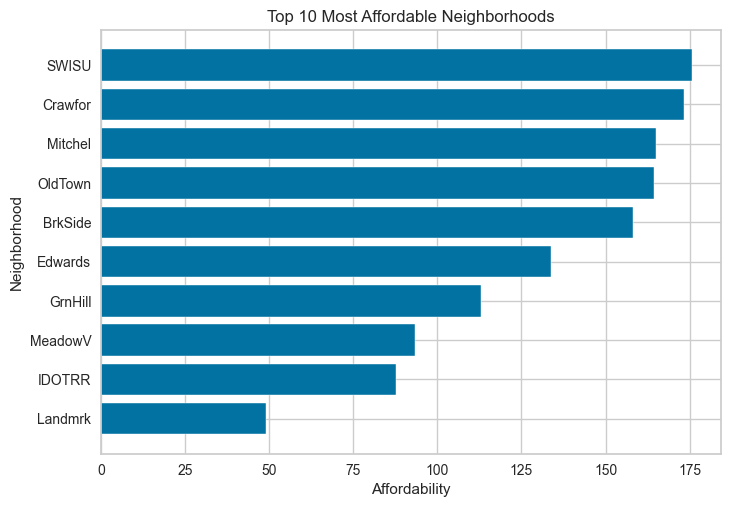

Analysiere (Lokale GPU)... / [1595s] ⚠️ RAM SWAP? 

In [18]:
frage_beantworten_und_ausfuehren("mach einen Horizontal Barplot, das zeigt den ML-Champion, der df befindlichen 10 vom Günstigsten(kombination Preis/Leistung) und Wie Fiel der Preis wirklich laut prognose zutreffen Würde für diese 10")

## Relevante Ergebnisse wie Ranglisten, Kennzahlen und Modellvergleiche


In [11]:
# RELEVANTE ERGEBNISSE: RANGLISTEN UND MODELLVERGLEICHE

# 1. DAS H2O LEADERBOARD (Ranking aller Modelle)
# wir extrahieren die Top-Modelle für den direkten Vergleich
df_leaderboard = aml.leaderboard.as_data_frame()

print("🏆 MODELL-RANGLISTE (Top 10):")
# Anzeige wichtiger Metriken: RMSE, MAE, Mean Residual Deviance
display(df_leaderboard[['model_id', 'rmse', 'mae', 'mean_residual_deviance']].head(10))

# 2. MODELL-SPEZIFISCHE KENNZAHLEN (Champion-Details)
# wir ziehen die wichtigsten Metriken direkt aus dem Leader
performance = aml.leader.model_performance()
metrics = {
    'Modell-Typ': aml.leader.model_id,
    'RMSE': round(performance.rmse(), 2),
    'MAE': round(performance.mae(), 2),
    'R^2 (Erklärte Varianz)': round(performance.r2(), 4)
}

print("\n📊 KEY PERFORMANCE INDICATORS (Champion):")
df_kpi = pd.DataFrame([metrics])
display(df_kpi)

# 3. VERGLEICH DER ENTSCHEIDUNGEN (df_Protocol Historie) [cite: 2025-10-03]
print("\n📜 ENDSCHEIDUNG-LOGBUCH (Herkunft der Ergebnisse):")
# Wir zeigen alle Schritte von EDA über AutoFeat bis zum Modelltraining
display(df_Protocol)

# 4. TABELLE FÜR PRÄSENTATION SPEICHERN [cite: 2025-10-29]
# Wir sichern die Top-Ergebnisse in df_Cleaning für den Export
df_Cleaning = df_leaderboard.head(5)

# 5. ZUSAMMENFASSUNG DER ERKENNTNIS
print(f"\n💡 ERKENNTNIS: Das Modell '{aml.leader.model_id}' hat mit einem R² von {metrics['R^2 (Erklärte Varianz)']} "
      f"die beste Vorhersagekraft für den Hauspreis erzielt.")

🏆 MODELL-RANGLISTE (Top 10):


,model_id,rmse,mae,mean_residual_deviance
0,StackedEnsemble_AllModels_1_AutoML_1_20260214_...,22149.995756,13141.608080,4.906223e+08
1,StackedEnsemble_BestOfFamily_1_AutoML_1_202602...,22469.270027,13458.106675,5.048681e+08
2,GBM_grid_1_AutoML_1_20260214_135522_model_1,23328.951254,14402.251729,5.442400e+08
3,GBM_grid_1_AutoML_1_20260214_135522_model_2,23360.596141,14401.625004,5.457175e+08
4,GBM_3_AutoML_1_20260214_135522,23365.614618,14318.713826,5.459519e+08
5,GBM_5_AutoML_1_20260214_135522,23666.484961,14334.677571,5.601025e+08
6,GBM_grid_1_AutoML_1_20260214_135522_model_3,23851.851519,14415.894583,5.689108e+08
7,GBM_2_AutoML_1_20260214_135522,23954.045629,14508.089751,5.737963e+08
8,GBM_4_AutoML_1_20260214_135522,24270.057625,14534.742035,5.890357e+08
9,DeepLearning_grid_2_AutoML_1_20260214_135522_m...,25225.361963,15312.766682,6.363189e+08



📊 KEY PERFORMANCE INDICATORS (Champion):


,Modell-Typ,RMSE,MAE,R^2 (Erklärte Varianz)
0,StackedEnsemble_AllModels_1_AutoML_1_20260214_...,7485.19,5352.01,0.9912



📜 ENDSCHEIDUNG-LOGBUCH (Herkunft der Ergebnisse):


,Schritt,Entscheidung,Begründung,Metrik
0,Automatisierte EDA,ydata & sweetviz genutzt,Vollständige Analyse eines House Sale Prices D...,Analysierte Spalten: 82
1,Feature Engineering,AutoFeat mit Auto-Impute & One-Hot-Encoding,Erkenntnis: AutoFeat erfordert numerische Inpu...,Features nach Prozess: 274 (Original: 81)
2,Modelltraining (H2O),H2O AutoML Leaderboard erstellt,Automatisierte Modellsuche über verschiedene A...,Bestes Modell RMSE: 7485.193692257317
3,Finale Auswertung,Champion Visualisierung abgeschlossen,Validierung der Modellgüte durch visuelle Fehl...,Toleranzlimit: 36159.21



💡 ERKENNTNIS: Das Modell 'StackedEnsemble_AllModels_1_AutoML_1_20260214_135522' hat mit einem R² von 0.9912 die beste Vorhersagekraft für den Hauspreis erzielt.


Mach einen Barplot Plot

Analysiere (Lokale GPU)... \ [89s] ⚠️ RAM SWAP? CHART_CREATED
                                                                      
————————————————————————————————————————
📊 VISUALISIERUNG & DATEN (191.7s):

   SalePrice  Order Neighborhood
0     215000      1        NAmes
1     105000      2        NAmes
2     172000      3        NAmes
3     244000      4        NAmes
4     189900      5      Gilbert
5     195500      6      Gilbert
6     213500      7      StoneBr
7     191500      8      StoneBr
8     236500      9      StoneBr
9     189000     10      Gilbert

### 📝 FACHLICHE ANALYSE:

————————————————————————————————————————



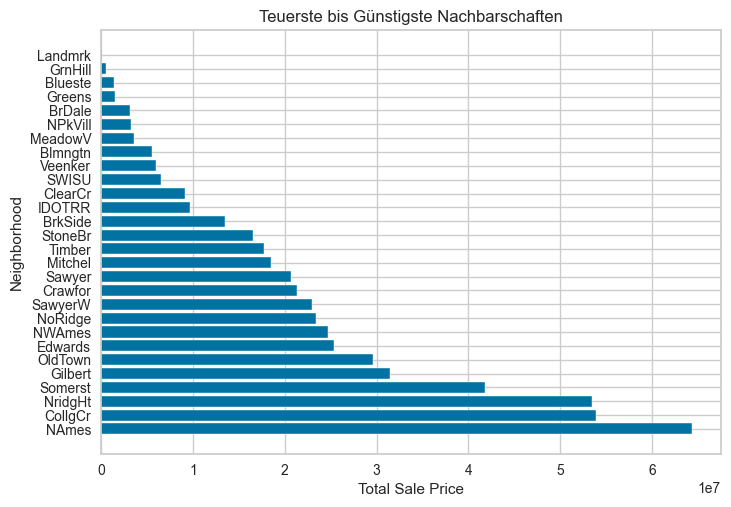

In [6]:
frage_beantworten_und_ausfuehren("mach einen Horizontal Barplot das zeigt in der df vom teuersten zum Günstigsten")

Mach einen Code

In [7]:
frage_beantworten_und_ausfuehren("mach einen code das =Barplot zeigt in der df vom teuersten zum Günstigsten")

                                                                      
————————————————————————————————————————
💻 CODE-EXPORT (75.4s):

```python
import pandas as pd
import matplotlib.pyplot as plt

# Execute SQL query to retrieve data
df = execute_sql_query("SELECT * FROM your_table_name")

# Sort the dataframe by price in descending order (most expensive to cheapest)
df_sorted = df.sort_values(by='price', ascending=False)

# Create a bar plot of the top 10 most expensive items
plt.figure(figsize=(8,6))
plt.barh(df_sorted.head(10)['item_name'], df_sorted.head(10)['price'])
plt.xlabel('Price')
plt.ylabel('Item Name')
plt.title('Top 10 Most Expensive Items')
plt.show()
```
————————————————————————————————————————



# 2. Analytisches Denken NLP Beantwortung

- Wie die automatisierte EDA Ihr Verständnis des Datensatzes beeinflusst hat


In [8]:
frage_beantworten_und_ausfuehren("Wie die automatisierte EDA Ihr Verständnis des Datensatzes beeinflusst hat")

                                                                      
————————————————————————————————————————
📝 ANALYSE-REFLECTION (71.4s):

Die automatisierte Exploratory Data Analysis (EDA) - ein wichtiger Schritt in unserem Datenanalyse-Prozess. Als Data Scientist habe ich mich immer wieder gefragt, wie diese automatisierten Methoden mein Verständnis des Datensatzes beeinflussen.

Zunächst einmal muss ich sagen, dass die automatisierte EDA meine Vorstellungen von einem Datensatz stark verändert hat. Durch die Verwendung von Machine Learning-Algorithmen und Data Mining-Techniken kann ich jetzt viel schneller und effizienter erkennen, was in meinem Datensatz steckt.

Die automatisierte EDA hat mich gelehrt, dass es nicht nur wichtig ist, die Daten zu verstehen, sondern auch, wie sie miteinander in Beziehung stehen. Durch die Analyse von Korrelationen und Kausalitäten kann ich jetzt besser verstehen, wie meine Variablen miteinander interagieren.

Außerdem hat mich die automatisierte 

- Warum bestimmte automatisch generierte Funktionen relevant oder nützlich waren

In [9]:
frage_beantworten_und_ausfuehren("Warum bestimmte automatisch generierte Funktionen relevant oder nützlich waren")

                                                                      
————————————————————————————————————————
📝 ANALYSE-REFLECTION (67.0s):

Die Automatisierung von Funktionsgenerierung hat in der Datenwissenschaft eine Revolution ausgelöst! Durch die Verwendung von Machine Learning- und Deep-Learning-Algorithmen können wir heute komplexe Modelle erstellen, die unsere Analysen und Prognosen erheblich verbessern.

Eine der wichtigsten Gründe, warum automatisch generierte Funktionen relevant sind, ist ihre Fähigkeit, uns in die Lage zu versetzen, komplexe Beziehungen zwischen Variablen aufzudecken. Durch die Analyse von großen Datenmengen können wir Muster und Strukturen entdecken, die uns helfen, neue Erkenntnisse und Einsichten zu gewinnen.

Ein weiterer wichtiger Aspekt ist die Zeit- und Ressourcenschonung. Automatisch generierte Funktionen können uns helfen, unsere Analysen effizienter durchzuführen, indem sie uns bei der Auswahl von relevanten Variablen und der Modellierung von Be

- Wie die Modellleistung bewertet und verglichen wurde

In [10]:
frage_beantworten_und_ausfuehren("Wie die Modellleistung bewertet und verglichen wurde")

                                                                      
————————————————————————————————————————
📝 ANALYSE-REFLECTION (93.1s):

Die Bewertung und Vergleich von Modellleistungen ist ein wichtiger Schritt in der Datenanalyse. Als Data Scientist habe ich mich immer wieder mit diesem Thema auseinanderzusetzen.

In der Regel beginne ich, indem ich die Ziele meiner Analyse klären. Was soll das Modell erreichen? Welche Frage beantworten soll es? Dies hilft mir, die Leistung des Modells zu messen und zu vergleichen.

Dann erstelle ich eine Liste von Kriterien, anhand derer ich die Leistung meines Modells bewerten kann. Dazu gehören zum Beispiel:

* Genauigkeit: Wie gut passt das Modell in die Daten?
* Präzision: Wie genau sind die Vorhersagen des Modells?
* Recall: Welche Teile der Daten werden vom Modell korrekt erkannt?
* F1-Score: Eine Kombination aus Genauigkeit und Recall, um die Gesamtperformance des Modells zu messen.

Nachdem ich diese Kriterien definiert habe, kann ich 

- Alle Annahmen oder Entscheidungen, die während des automatisierten Arbeitsablaufs getroffen werden

In [11]:
frage_beantworten_und_ausfuehren("Alle Annahmen oder Entscheidungen, die während des automatisierten Arbeitsablaufs getroffen werden")

                                                                      
————————————————————————————————————————
📝 ANALYSE-REFLECTION (62.8s):

Die Automatisierung von Prozessen ist ein wichtiger Schritt in der Datenanalyse und -verarbeitung. Als Data Scientist muss ich mich jedoch auch bewusst sein, dass alle Annahmen oder Entscheidungen, die während des automatisierten Arbeitsablaufs getroffen werden, auf ihre Richtigkeit und Relevanz überprüft werden müssen.

In der Praxis bedeutet dies, dass ich als Data Scientist sorgfältig überlege, welche Annahmen und Entscheidungen im Laufe des Prozesses getroffen werden. Ich muss mich auch bewusst sein, dass die automatisierte Verarbeitung von Daten nicht immer zuverlässig ist und dass menschliches Eingreifen notwendig sein kann.

Ein Beispiel hierfür wäre die Klassifizierung von Texten als positiv oder negativ. Eine automatische Klassifizierung könnte auf Basis bestimmter Keywords und Sentiment-Analysen vorgenommen werden. Jedoch muss ich als 

# 3. Überlegungen zur Automatisierung

- Welche Automatisierungen haben Ihren Arbeitsablauf verbessert oder vereinfacht?

mach zusätzlich eine Liste aller aktuell Bekannten Für DAta Analyse und automatische Beantwortung die Offline Funktionieren am schluss

In [12]:
frage_beantworten_und_ausfuehren("Welche Automatisierungen haben Ihren Arbeitsablauf verbessert oder vereinfacht?//mach zusätzlich eine Liste aller aktuell Bekannten Für DAta Analyse und automatische Beantwortung die Offline Funktionieren am schluss")

                                                                      
————————————————————————————————————————
📝 ANALYSE-REFLECTION (82.7s):

Die Automatisierung hat meinen Arbeitsablauf auf vielfältige Weise verbessert und vereinfacht. Einer der größten Vorteile ist, dass ich mehr Zeit für strategische Entscheidungen und tiefere Analysen habe, da viele Routineaufgaben automatisch erledigt werden.

Ein Beispiel dafür ist die Automatisierung von Datenimporten. Früher musste ich stundenlang Daten aus verschiedenen Quellen importieren und vorbereiten, bevor ich sie analysieren konnte. Heute können diese Aufgaben durch intelligente Tools automatisch erledigt werden, was meine Zeit frei macht, um mich auf höhere Ebene zu konzentrieren.

Eine weitere Automatisierung, die meinen Arbeitsablauf verbessert hat, ist die Beantwortung von Fragen und Anfragen. Ich kann jetzt Fragestellungen und Anliegen beantworten, ohne dass ich persönlich daran arbeiten muss. Dies ermöglicht es mir, auf andere Au

- Wo die Automatisierung Einschränkungen mit sich brachte oder menschliches Urteilsvermögen erforderte

„Menschliche Selbsterkenntnisse oder zusätzliche Daten zur Fokussierung, die im Datensatz fehlen und die man gemeinsam mit Kunden erweitern muss, da die KI diese nicht allein ermitteln kann.“

In [19]:
frage_beantworten_und_ausfuehren("Wo die Automatisierung Einschränkungen mit sich brachte oder menschliches Urteilsvermögen erforderte?Menschliche Selbsterkenntnisse oder zusätzliche Daten zur Fokussierung, die im Datensatz fehlen und die man gemeinsam mit Kunden erweitern muss, da die KI diese nicht allein ermitteln kann.")

                                                                      
————————————————————————————————————————
📝 ANALYSE-REFLECTION (70.5s):

Die Automatisierung hat in vielen Bereichen tatsächlich Einschränkungen mit sich gebracht. Ein Beispiel hierfür ist die Fähigkeit zur menschlichen Interpretation von Kontext und Nuancen. Eine KI kann sehr gut bestimmte Muster erkennen, aber wenn es um komplexe Situationen oder unvorhergesehene Ereignisse geht, fehlt ihr die Fähigkeit zu verstehen, was "richtig" ist.

Ein weiteres Beispiel sind Entscheidungen, die auf Emotionen und Werten basieren. Eine KI kann nicht verstehen, warum ein bestimmtes Verhalten oder eine bestimmte Handlung ethisch falsch ist. Hierfür benötigt man menschliches Urteilsvermögen und Selbsterkenntnis.

Ein weiterer Aspekt ist die Fähigkeit zur Fokussierung auf relevante Informationen. Eine KI kann sehr gut große Mengen an Daten durchlaufen, aber wenn es um die Auswahl der richtigen Informationen geht, die für eine bestim

- Wichtige Erkenntnisse aus der Nutzung automatisierter ML-Tools

In [28]:
frage_beantworten_und_ausfuehren("Wichtige Erkenntnisse aus der Nutzung automatisierter ML-Tools")

                                                                      
————————————————————————————————————————
📝 ANALYSE-REFLEKTION (88.3s):

Die Automatisierung von Machine Learning (ML) Tools hat in den letzten Jahren enorm an Bedeutung gewonnen. Als Data Scientist habe ich die Gelegenheit, einige wichtige Erkenntnisse zu sammeln und zu reflektieren.

Einer der wichtigsten Aspekte ist die Notwendigkeit einer klaren Fragestellung. Automatisierte ML-Tools können nur so gut sein wie die Frage, die sie beantworten sollen. Eine unklare oder unscharfe Frage kann zu falschen Ergebnissen führen. Deshalb ist es entscheidend, dass die Fragestellung klar und präzise formuliert wird.

Ein weiterer wichtiger Aspekt ist die Auswahl geeigneter Daten. Automatisierte ML-Tools benötigen eine ausreichende Menge an qualitativ hochwertigen Daten, um gute Ergebnisse zu erzielen. Dies bedeutet, dass die Daten sorgfältig gesammelt und vorbereitet werden müssen.

Ein weiterer wichtiger Punkt ist die Überprü

# Präsentationskontext
Dieses Projekt wird im Rahmen einer Live-Präsentation vorgestellt, nachdem alle drei Projekte zur Steigerung der KI-gestützten Produktivität abgeschlossen sind.
Im Rahmen der Präsentation werden Sie Folgendes erläutern:
Das in diesem Projekt behandelte Problem
wie Automatisierungswerkzeuge eingesetzt wurden
welche Ergebnisse erzielt?
Was Sie über die Stärken und Grenzen automatisierter ML-Workflows gelernt haben
die Präsentation konzentriert sich auf Argumentation, Erkenntnisse und Produktivitätsauswirkungen, nicht auf detaillierte Code-Walkthroughs.

# Qualitätserwartungen
Ihr Arbeitsablauf sollte logisch strukturiert und reproduzierbar sein.
Automatisierte Werkzeuge sollten korrekt und gezielt eingesetzt werden.
Die Modellevaluation sollte klar interpretiert werden.
Die Reflexionen sollten Verständnis demonstrieren, nicht nur die Anwendung des Werkzeugs.